# Lab 3 – Image Manipulations using OpenCV

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = '../images'

def show(images, titles, cols=None, size=4):
    """Display images inline (replaces cv2.imshow, which does not work well in Jupyter)."""
    cols = cols or len(images)
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(size * cols, size * rows))
    for i, (im, t) in enumerate(zip(images, titles), 1):
        plt.subplot(rows, cols, i)
        if im.ndim == 2:
            plt.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(t); plt.axis('off')
    plt.tight_layout(); plt.show()

In [2]:
# no colour sample image in repo: build input.jpg from cameraman.tiff once
src = os.path.join(IMG_DIR, 'cameraman.tiff')
inp = os.path.join(IMG_DIR, 'input.jpg')
if not os.path.exists(inp):
    g = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
    cv2.imwrite(inp, cv2.applyColorMap(g, cv2.COLORMAP_TURBO))

## Step 1: Read an image

<class 'numpy.ndarray'>
shape: (256, 256, 3) dtype: uint8


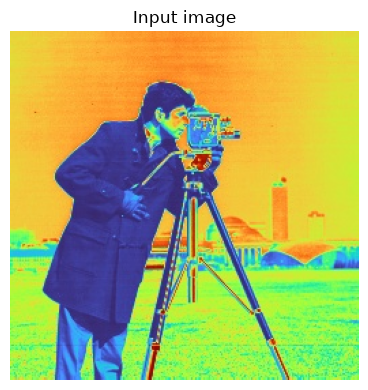

In [3]:
img = cv2.imread(inp)
print(type(img))
print('shape:', img.shape, 'dtype:', img.dtype)   # (height, width, channels) – OpenCV stores BGR
show([img], ['Input image'])

## Step 2: Load an image as grayscale

shape: (256, 256)


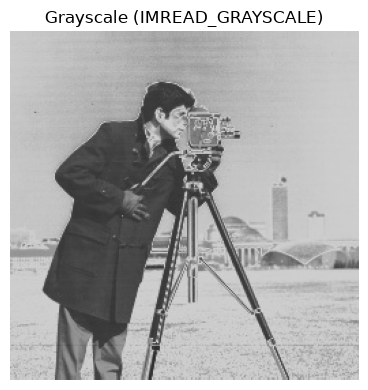

In [4]:
gray_img = cv2.imread(inp, cv2.IMREAD_GRAYSCALE)
print('shape:', gray_img.shape)
show([gray_img], ['Grayscale (IMREAD_GRAYSCALE)'])

## Step 3: Save an image

In [5]:
cv2.imwrite(os.path.join(IMG_DIR, 'output.jpg'), gray_img)
print('saved ->', os.path.exists(os.path.join(IMG_DIR, 'output.jpg')))

saved -> True


## Step 4: Convert an image to different colour spaces

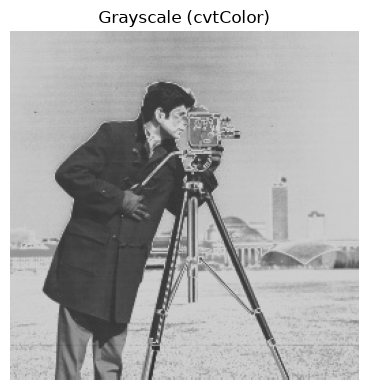

In [6]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show([gray_img], ['Grayscale (cvtColor)'])

In [7]:
flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print(len(flags), 'flags'); print(flags[:15], '...')

374 flags
['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB'] ...


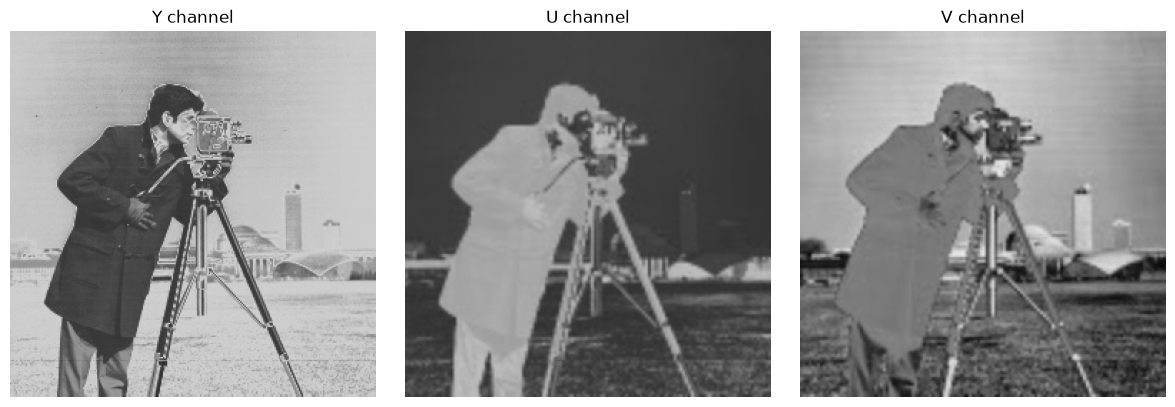

In [8]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
show([yuv_img[:, :, 0], yuv_img[:, :, 1], yuv_img[:, :, 2]], ['Y channel', 'U channel', 'V channel'])

# Assessment
## Task 1: Geometric transformations

### 1a. Increase the size of the image

original: (256, 256) -> enlarged: (512, 512)


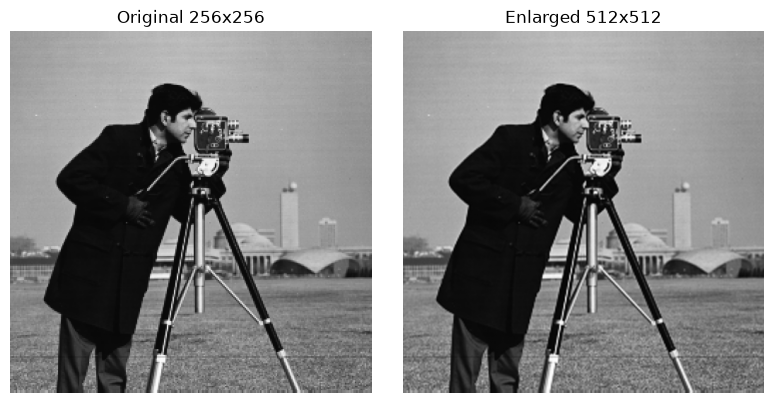

In [9]:
g = cv2.imread(src, cv2.IMREAD_GRAYSCALE)      # grayscale original used for the tasks
h, w = g.shape
enlarged = cv2.resize(g, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
print('original:', g.shape, '-> enlarged:', enlarged.shape)
show([g, enlarged], ['Original %dx%d' % (w, h), 'Enlarged %dx%d' % enlarged.shape[::-1]])

### 1b. Rotate the image by 120°

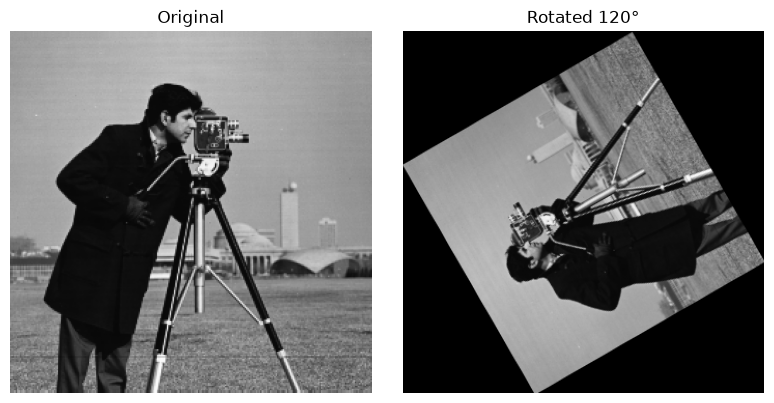

In [10]:
angle = 120
M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
cos, sin = abs(M[0, 0]), abs(M[0, 1])
nw, nh = int(h * sin + w * cos), int(h * cos + w * sin)
M[0, 2] += nw / 2 - w / 2
M[1, 2] += nh / 2 - h / 2
rotated = cv2.warpAffine(g, M, (nw, nh))
show([g, rotated], ['Original', 'Rotated %d°' % angle])

### 1c. Shear operations

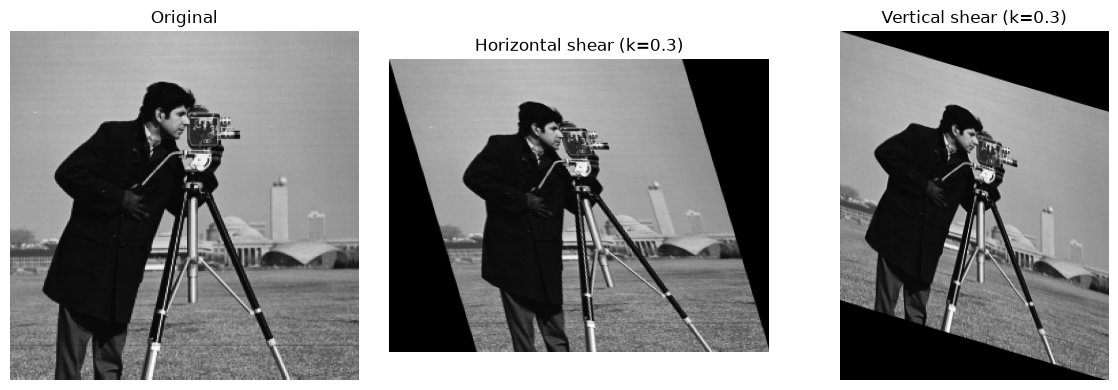

In [11]:
k = 0.3
shear_x = cv2.warpAffine(g, np.float32([[1, k, 0], [0, 1, 0]]), (int(w + k * h), h))
shear_y = cv2.warpAffine(g, np.float32([[1, 0, 0], [k, 1, 0]]), (w, int(h + k * w)))
show([g, shear_x, shear_y], ['Original', 'Horizontal shear (k=0.3)', 'Vertical shear (k=0.3)'])

## Task 2: Intensity transformations

### 2a. Negative image

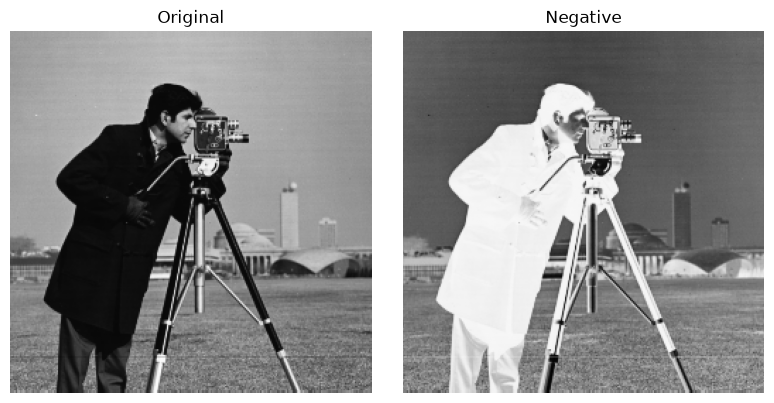

In [12]:
negative = 255 - g
show([g, negative], ['Original', 'Negative'])

### 2b. Log transformation

c = 46.051


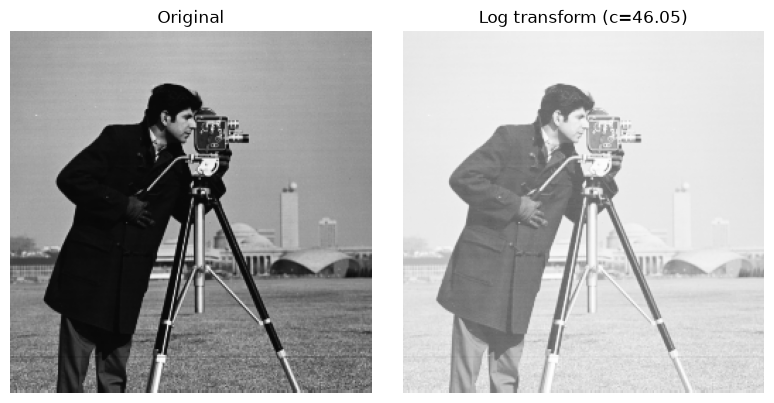

In [13]:
r = g.astype(np.float64)
c = 255 / np.log(1 + r.max())
log_img = np.uint8(c * np.log(1 + r))
print('c =', round(c, 3))
show([g, log_img], ['Original', 'Log transform (c=%.2f)' % c])

### 2c. Power-law

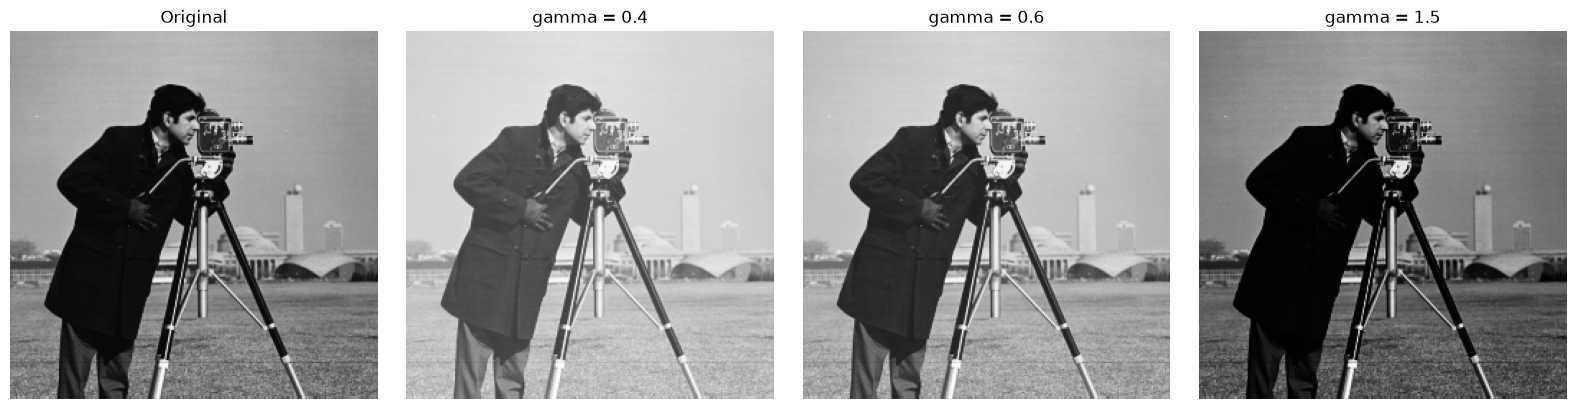

In [14]:
def gamma_t(im, gamma, c=1.0):
    return np.uint8(np.clip(c * (im / 255.0) ** gamma, 0, 1) * 255)

gammas = [0.4, 0.6, 1.5]
show([g] + [gamma_t(g, gm) for gm in gammas], ['Original'] + ['gamma = %s' % gm for gm in gammas], cols=4)

std dev  original: 62.3   gamma=0.6: 61.5


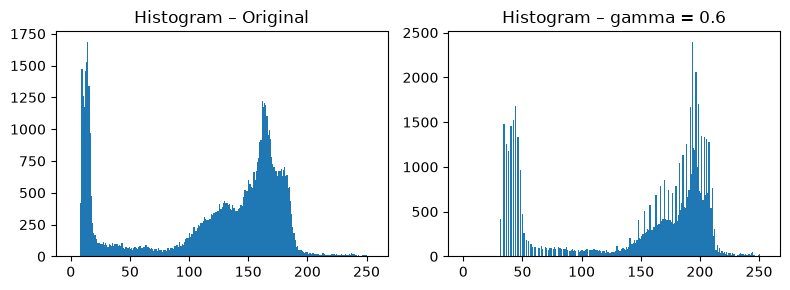

In [15]:
chosen = gamma_t(g, 0.6)
print('std dev  original: %.1f   gamma=0.6: %.1f' % (g.std(), chosen.std()))
plt.figure(figsize=(8, 3))
for i, (im, t) in enumerate([(g, 'Original'), (chosen, 'gamma = 0.6')], 1):
    plt.subplot(1, 2, i); plt.hist(im.ravel(), bins=256, range=(0, 255)); plt.title('Histogram – ' + t)
plt.tight_layout(); plt.show()